Question c

Processing first image...
ret found
(408, 1, 2)


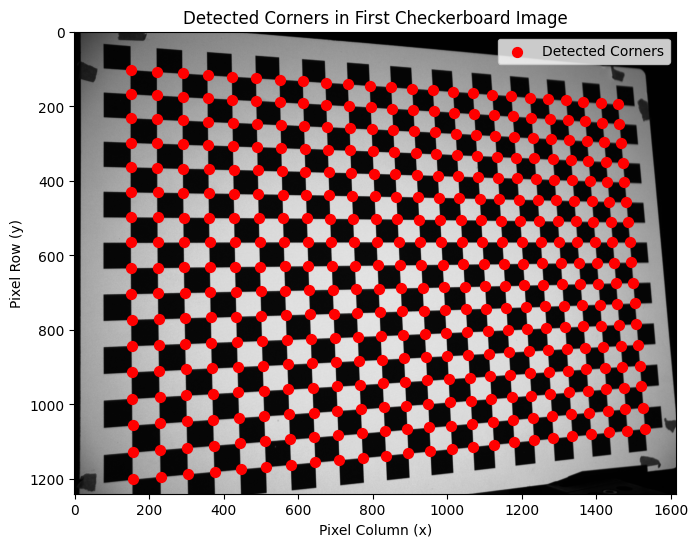

Corners successfully detected in the first image.

Processing all images...

Processing image 1: 1.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 1.

Processing image 2: 10.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 2.

Processing image 3: 11.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 3.

Processing image 4: 12.png
Failed to detect corners in image 4: 12.png

Processing image 5: 13.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 5.

Processing image 6: 14.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 6.

Processing image 7: 15.png
Failed to detect corners in image 7: 15.png

Processing image 8: 16.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 8.

Processing image 9: 17.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 9.

Processing image 10: 18.png
ret found
(408, 1, 2)
Successfully detected 408 corners in image 10.

Processing

In [124]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Define checkerboard size (number of inner corners per row and column)
CHECKERBOARD = (17, 24)  # Example: 9x6 inner corners

objp = np.zeros((17*24,3), np.float32)
objp[:,:2] = np.mgrid[0:17,0:24].T.reshape(-1,2)
# Arrays to store object points and image points from all the images.
objpoints = [] # 3d point in real world space
imgpoints = [] # 2d points in image plane.

# Directory containing the checkerboard images
DATA_DIR = "Data/Calibration/NoPattern"
image_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.png")))  # Adjust extension if needed

# Function to detect and plot corners
def detect_and_plot_corners(image_path, plot_title, save_path=None):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return False, None, img
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect checkerboard corners
    ret, corners=cv2.findChessboardCornersSB(gray, CHECKERBOARD, cv2.CALIB_CB_NORMALIZE_IMAGE,cv2.CALIB_CB_EXHAUSTIVE)

    if ret:
        print("ret found")
        objpoints.append(objp)
        # Refine corner positions
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
            criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001))
        print(corners.shape)
        imgpoints.append(corners)
        # Draw corners on image for visualization
        img_with_corners = img.copy()
        cv2.drawChessboardCorners(img_with_corners, CHECKERBOARD, corners, ret)

        # Plot corners in pixel coordinates
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        corners = corners.squeeze()  # Shape: (N, 2)
        plt.scatter(corners[:, 0], corners[:, 1], c='red', s=50, label='Detected Corners')
        plt.title(plot_title)
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        plt.legend()
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()

        return True, corners, img_with_corners
    else:
        # Plot the image even if detection failed
        plt.figure(figsize=(8, 6))
        plt.imshow(img, cmap='gray')
        plt.title(f"{plot_title} (No Corners Detected)")
        plt.xlabel('Pixel Column (x)')
        plt.ylabel('Pixel Row (y)')
        if save_path:
            plt.savefig(save_path)
            plt.close()
        else:
            plt.show()
        return False, None, img

# Part a: Detect and plot corners for the first image
if image_files:
    print("Processing first image...")
    success, corners, _ = detect_and_plot_corners(
        image_files[0], 
        "Detected Corners in First Checkerboard Image"
    )
    if success:
        print("Corners successfully detected in the first image.")
    else:
        print("Failed to detect corners in the first image.")

# Part b: Detect corners in all 30 images and report failures
print("\nProcessing all images...")
failed_images = []
for i, img_path in enumerate(image_files[:30]):  # Limit to 30 images
    print(f"\nProcessing image {i+1}: {os.path.basename(img_path)}")
    save_path = f"output_image_{i+1}.png"
    success, corners, _ = detect_and_plot_corners(
        img_path, 
        f"Checkerboard Image {i+1}", 
        save_path=save_path
    )
    if not success:
        print(f"Failed to detect corners in image {i+1}: {os.path.basename(img_path)}")
        failed_images.append((i+1, img_path, save_path))
    else:
        print(f"Successfully detected {len(corners)} corners in image {i+1}.")

# Report summary
print("\nSummary:")
print(f"Processed {min(len(image_files), 30)} images.")
print(f"Number of images with failed corner detection: {len(failed_images)}")
if failed_images:
    print("Images with failed corner detection:")
    for idx, img_path, save_path in failed_images:
        print(f"Image {idx}: {os.path.basename(img_path)} (see {save_path})")
else:
    print("All corners successfully detected in all images.")

img = cv2.imread("Data/Calibration/NoPattern/1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
camera_width=img.shape[0]
camera_height=img.shape[1]
Number_of_Images=19
criteriaEnd = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001)  # Termination criteria for estimateCameraParams
reprojectionError1, camera_matrix1, dist_coeffs1, rotation_vectors, translation_vectors = cv2.calibrateCamera(
    objpoints, imgpoints, (camera_width, camera_height), None, None,
    flags=cv2.CALIB_FIX_K4 + cv2.CALIB_FIX_K5 + cv2.CALIB_FIX_K6,criteria=criteriaEnd
)
print(reprojectionError1)

In [109]:
newcameramtx, roi = cv2.getOptimalNewCameraMatrix(camera_matrix1, 
                                                  dist_coeffs1, 
                                                  (camera_width,camera_height), 
                                                  1, 
                                                  (camera_width,camera_height)
                                                  )

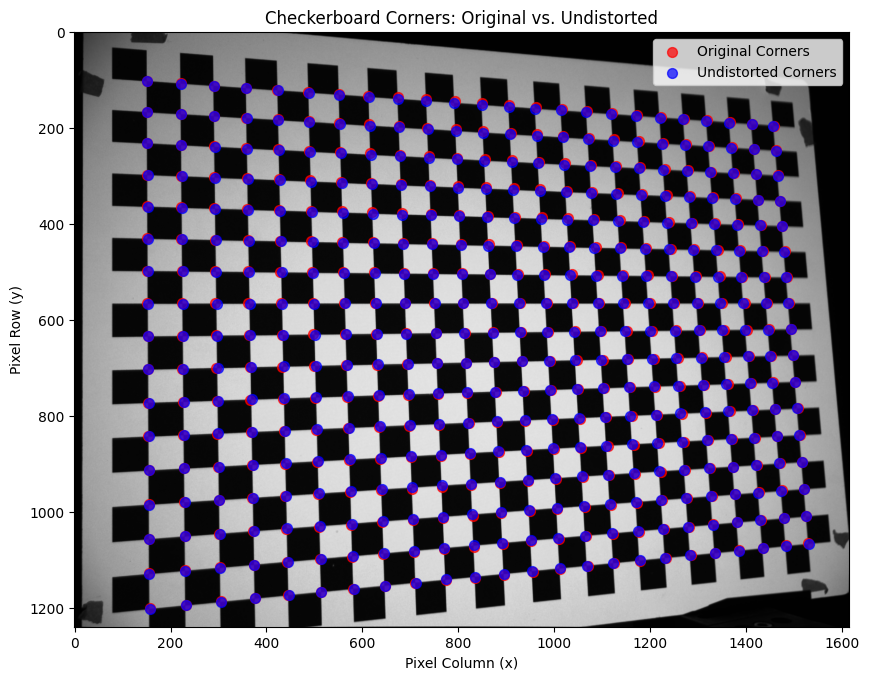

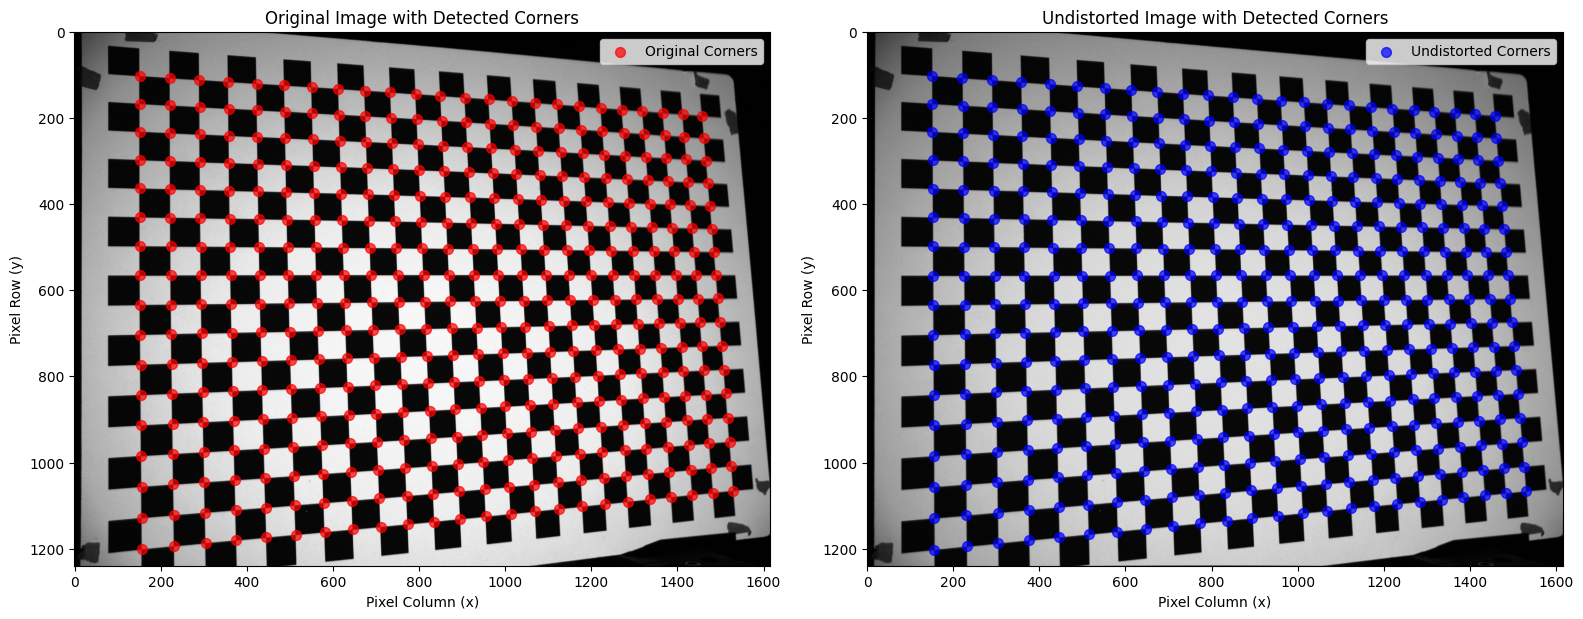

In [110]:
import cv2
import matplotlib.pyplot as plt
import numpy as np



# Load the image
img = cv2.imread("Data/Calibration/NoPattern/1.png")
if img is None:
    raise FileNotFoundError("Image not found: Data/Calibration/NoPattern/1.png")

# Convert to grayscale for corner detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect corners in the original (distorted) image
ret, corners_orig = cv2.findChessboardCornersSB(
    gray, CHECKERBOARD, 
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
)
if ret:
    # Refine corners
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.0001)
    corners_orig = cv2.cornerSubPix(gray, corners_orig, (11, 11), (-1, -1), criteria)
else:
    raise ValueError("Checkerboard corners not detected in original image")

# Undistort the image
un_dst_img = cv2.undistort(img, camera_matrix1, dist_coeffs1, None, newcameramtx)

# Convert undistorted image to grayscale for corner detection
un_dst_gray = cv2.cvtColor(un_dst_img, cv2.COLOR_BGR2GRAY)

# Detect corners in the undistorted image
ret, corners_undist = cv2.findChessboardCornersSB(
    un_dst_gray, CHECKERBOARD, 
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
)
if ret:
    # Refine corners
    corners_undist = cv2.cornerSubPix(un_dst_gray, corners_undist, (11, 11), (-1, -1), criteria)
else:
    raise ValueError("Checkerboard corners not detected in undistorted image")

# Convert undistorted image to RGB for plotting
un_dst_rgb = cv2.cvtColor(un_dst_img, cv2.COLOR_BGR2RGB)

# Plot the undistorted image with both sets of corners
plt.figure(figsize=(10, 8))
plt.imshow(un_dst_rgb)
# Plot original corners (red)
corners_orig = corners_orig.squeeze()  # Shape: (N, 2)
plt.scatter(corners_orig[:, 0], corners_orig[:, 1], c='red', s=50, label='Original Corners', alpha=0.7)
# Plot undistorted corners (blue)
corners_undist = corners_undist.squeeze()  # Shape: (N, 2)
plt.scatter(corners_undist[:, 0], corners_undist[:, 1], c='blue', s=50, label='Undistorted Corners', alpha=0.7)
plt.title('Checkerboard Corners: Original vs. Undistorted')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()
plt.show()
plt.close()

# Create side-by-side plots
plt.figure(figsize=(16, 6))

# Left subplot: Original image with original corners
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
corners_orig = corners_orig.squeeze()  # Shape: (N, 2)
plt.scatter(corners_orig[:, 0], corners_orig[:, 1], c='red', s=50, label='Original Corners', alpha=0.7)
plt.title('Original Image with Detected Corners')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()

# Right subplot: Undistorted image with undistorted corners
plt.subplot(1, 2, 2)
plt.imshow(un_dst_rgb)
corners_undist = corners_undist.squeeze()  # Shape: (N, 2)
plt.scatter(corners_undist[:, 0], corners_undist[:, 1], c='blue', s=50, label='Undistorted Corners', alpha=0.7)
plt.title('Undistorted Image with Detected Corners')
plt.xlabel('Pixel Column (x)')
plt.ylabel('Pixel Row (y)')
plt.legend()

# Adjust layout and display
plt.tight_layout()
plt.show()
plt.close()

Question D

-3.0490457723982547
2.91238898038469


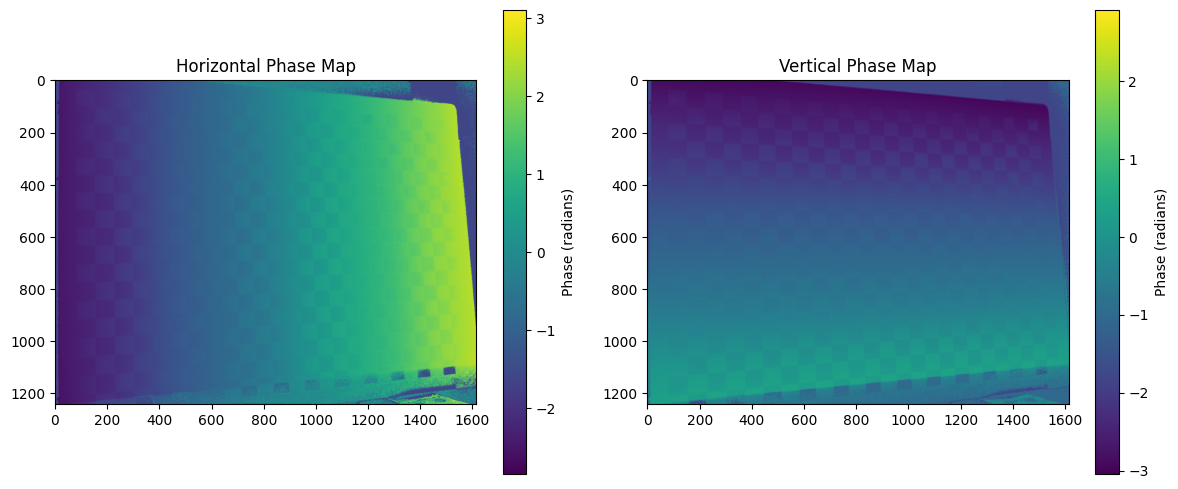

Camera-Projector Correspondence (first 5 corners):
Corner 0: Camera (156.40, 1202.06) -> Projector (-1322.12, 167.24)
Corner 1: Camera (155.97, 1129.18) -> Projector (-1316.14, 68.31)
Corner 2: Camera (155.62, 1056.64) -> Projector (-1322.70, -48.39)
Corner 3: Camera (155.34, 984.82) -> Projector (-1325.79, -163.13)
Corner 4: Camera (154.99, 913.45) -> Projector (-1316.62, -283.34)
Corner 5: Camera (154.61, 842.79) -> Projector (-1322.66, -382.00)
Corner 6: Camera (154.36, 772.54) -> Projector (-1305.52, -484.69)
Corner 7: Camera (153.96, 703.05) -> Projector (-1313.89, -596.28)
Corner 8: Camera (153.59, 634.01) -> Projector (-1301.89, -744.05)
Corner 9: Camera (153.28, 565.77) -> Projector (-1318.20, -825.67)
Corner 10: Camera (152.93, 497.92) -> Projector (-1310.21, -931.75)
Corner 11: Camera (152.58, 430.50) -> Projector (-1304.79, -1050.63)
Corner 12: Camera (152.38, 363.79) -> Projector (-1298.58, -1162.02)
Corner 13: Camera (152.06, 297.61) -> Projector (-1310.34, -1276.87)
Corne

In [111]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Projector resolution
PROJ_COLS = 3840  # Columns
PROJ_ROWS = 2160  # Rows

# Phase ranges
HORIZ_PHASE_RANGE = 2 * np.pi  # [0, 2π] for horizontal (columns)
VERT_PHASE_RANGE = 1.125 * np.pi  # [0, 1.125π] for vertical (rows)

# Checkerboard size (inner corners, adjust as needed)
CHECKERBOARD = (17, 24)

def compute_phase_map(I0, I1, I2, I3):
    """
    Compute phase map using four-phase shift algorithm.
    I0, I1, I2, I3: Grayscale images with phase shifts 0, π/2, π, 3π/2.
    Returns: Phase map in radians.
    """
    # Ensure images are float for calculations
    I0 = I0.astype(float)
    I1 = I1.astype(float)
    I2 = I2.astype(float)
    I3 = I3.astype(float)
    
    # Four-phase shift formula: φ = atan2(I3 - I1, I0 - I2)
    numerator = I3 - I1
    denominator = I0 - I2
    # Avoid division by zero
    phase = np.arctan2(numerator, denominator)  # Phase in [-π, π]
    # Unwrap phase to [0, 2π]
    phase = np.where(phase < 0, phase + 2 * np.pi, phase)
    return phase

def load_phase_images(base_path, pos_num="pos1"):
    """
    Load eight phase-shifted images: 1-4 (horizontal), 5-8 (vertical).
    base_path: Directory path (e.g., 'Data/Calibration/NoPattern').
    Returns: Two tuples of four grayscale images (horizontal: I0-I3, vertical: I0-I3).
    """
    # Horizontal fringes: suffixes 1, 2, 3, 4
    h_I0 = cv2.imread(f"{base_path}/{pos_num}_1.png", cv2.IMREAD_GRAYSCALE)
    h_I1 = cv2.imread(f"{base_path}/{pos_num}_2.png", cv2.IMREAD_GRAYSCALE)
    h_I2 = cv2.imread(f"{base_path}/{pos_num}_3.png", cv2.IMREAD_GRAYSCALE)
    h_I3 = cv2.imread(f"{base_path}/{pos_num}_4.png", cv2.IMREAD_GRAYSCALE)
    
    # Vertical fringes: suffixes 5, 6, 7, 8
    v_I0 = cv2.imread(f"{base_path}/{pos_num}_5.png", cv2.IMREAD_GRAYSCALE)
    v_I1 = cv2.imread(f"{base_path}/{pos_num}_6.png", cv2.IMREAD_GRAYSCALE)
    v_I2 = cv2.imread(f"{base_path}/{pos_num}_7.png", cv2.IMREAD_GRAYSCALE)
    v_I3 = cv2.imread(f"{base_path}/{pos_num}_8.png", cv2.IMREAD_GRAYSCALE)
    
    # Check for missing images
    if any(img is None for img in [h_I0, h_I1, h_I2, h_I3, v_I0, v_I1, v_I2, v_I3]):
        raise FileNotFoundError(f"Failed to load phase images from {base_path}")
    
    return (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3)

def phase_to_projector_coords(phase_h, phase_v):
    """
    Convert phase values to projector coordinates.
    phase_h: Horizontal phase map [0, 2π].
    phase_v: Vertical phase map [0, 1.125π].
    Returns: Projector columns [0, 3840], rows [0, 2160].
    """
    # Normalize phase to projector coordinates
    proj_cols = (phase_h / HORIZ_PHASE_RANGE) * PROJ_COLS  # [0, 3840]
    proj_rows = (phase_v / VERT_PHASE_RANGE) * PROJ_ROWS  # [0, 2160]
    return proj_cols, proj_rows

def shift_phase_jump(phase_map, offset):
    """Shift phase jump by adding offset and rewrapping."""
    return np.angle(np.exp(1j * (phase_map + offset)))

def main():
    # Base path for images (adjust as needed)
    base_path_no_pattern = "Data/Calibration/NoPattern"
    base_path_pattern = "Data/Calibration/Patterns"
    
    # Make sure to access the global variables from camera calibration from previous step
    global camera_matrix1, dist_coeffs1, rotation_vectors, translation_vectors

    # Load checkerboard image
    checker_img = cv2.imread(f"{base_path_no_pattern}/1.png")
    if checker_img is None:
        raise FileNotFoundError("Checkerboard image not found")
    
    # Undistort checkerboard image
    checker_undist = cv2.undistort(checker_img, camera_matrix1, dist_coeffs1, None, newcameramtx)
    gray_undist = cv2.cvtColor(checker_undist, cv2.COLOR_BGR2GRAY)
    
    # Detect checkerboard corners
    ret, corners = cv2.findChessboardCornersSB(
        gray_undist, CHECKERBOARD,
        flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
    )
    if not ret:
        raise ValueError("Checkerboard corners not detected")
    
    # Refine corners
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.0001)
    corners = cv2.cornerSubPix(gray_undist, corners, (11, 11), (-1, -1), criteria)
    corners = corners.squeeze()  # Shape: (N, 2)
    
    # Load phase-shifted images
    (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3) = load_phase_images(base_path_pattern)
    
    # Undistort phase images
    h_I0 = cv2.undistort(h_I0, camera_matrix1, dist_coeffs1, None, newcameramtx)
    h_I1 = cv2.undistort(h_I1, camera_matrix1, dist_coeffs1, None, newcameramtx)
    h_I2 = cv2.undistort(h_I2, camera_matrix1, dist_coeffs1, None, newcameramtx)
    h_I3 = cv2.undistort(h_I3, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I0 = cv2.undistort(v_I0, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I1 = cv2.undistort(v_I1, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I2 = cv2.undistort(v_I2, camera_matrix1, dist_coeffs1, None, newcameramtx)
    v_I3 = cv2.undistort(v_I3, camera_matrix1, dist_coeffs1, None, newcameramtx)
    
    # Compute phase maps
    phase_h = compute_phase_map(h_I0, h_I1, h_I2, h_I3)  # Horizontal phase [0, 2π]
    phase_v = compute_phase_map(v_I0, v_I1, v_I2, v_I3)  # Vertical phase [0, 1.125π]
    
    
    h_offset = -1.6 # Adjust this value for horizontal map
    v_offset = -1.8  # Adjust this value for vertical map

    # Apply the phase shift
    new_horizontal_phase = shift_phase_jump(phase_h, h_offset)
    new_vertical_phase = shift_phase_jump(phase_v, v_offset)
    print(np.min(new_vertical_phase))
    print(np.max(new_vertical_phase))

    # Extract phase at checkerboard corners
    corner_phases_h = []
    corner_phases_v = []
    for corner in corners:
        x, y = int(corner[0]), int(corner[1])  # Pixel coordinates
        corner_phases_h.append(new_horizontal_phase[y, x])
        corner_phases_v.append(new_vertical_phase[y, x])
    corner_phases_h = np.array(corner_phases_h)
    corner_phases_v = np.array(corner_phases_v)
    
    # Convert phase to projector coordinates
    proj_cols, proj_rows = phase_to_projector_coords(corner_phases_h, corner_phases_v)
    
    # Store camera-projector correspondence
    correspondence = []
    for i, corner in enumerate(corners):
        cam_x, cam_y = corner  # Camera pixel coordinates
        proj_col, proj_row = proj_cols[i], proj_rows[i]  # Projector coordinates
        correspondence.append({
            'camera': (cam_x, cam_y),
            'projector': (proj_col, proj_row)
        })
    
    # Visualize phase maps (optional)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(new_horizontal_phase, cmap='viridis')
    plt.title('Horizontal Phase Map')
    plt.colorbar(label='Phase (radians)')
    plt.subplot(1, 2, 2)
    plt.imshow(new_vertical_phase, cmap='viridis')
    plt.title('Vertical Phase Map')
    plt.colorbar(label='Phase (radians)')
    plt.tight_layout()
    plt.show()
    
    # Print correspondence for the first few corners
    print("Camera-Projector Correspondence (first 5 corners):")
    for i, corr in enumerate(correspondence[:]):
        print(f"Corner {i}: Camera ({corr['camera'][0]:.2f}, {corr['camera'][1]:.2f}) "
              f"-> Projector ({corr['projector'][0]:.2f}, {corr['projector'][1]:.2f})")
    
    return correspondence

if __name__ == "__main__":
    correspondence = main()

Testing

In [139]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates

# Projector resolution
PROJ_COLS = 3840  # Columns
PROJ_ROWS = 2160  # Rows

# Phase ranges
HORIZ_PHASE_RANGE = 2 * np.pi  # [0, 2π] for horizontal (columns)
VERT_PHASE_RANGE = 1.125 * np.pi  # [0, 1.125π] for vertical (rows)

# Checkerboard size (inner corners, adjust as needed)
CHECKERBOARD = (17, 24)

# Checkerboard square size (in mm, adjust as needed)
SQUARE_SIZE = 15.0  # mm

def compute_phase_map(I0, I1, I2, I3):
    """
    Compute phase map using four-phase shift algorithm.
    I0, I1, I2, I3: Grayscale images with phase shifts 0, π/2, π, 3π/2.
    Returns: Phase map in radians.
    """
    I0 = I0.astype(float)
    I1 = I1.astype(float)
    I2 = I2.astype(float)
    I3 = I3.astype(float)
    
    numerator = I3 - I1
    denominator = I0 - I2
    phase = np.arctan2(numerator, denominator)  # Phase in [-π, π]
    phase = np.where(phase < 0, phase + 2 * np.pi, phase)  # [0, 2π]
    return phase

def load_phase_images(base_path, pos_num="pos1"):
    """
    Load eight phase-shifted images: 1-4 (horizontal), 5-8 (vertical).
    base_path: Directory path (e.g., 'Data/Calibration/NoPattern').
    Returns: Two tuples of four grayscale images (horizontal: I0-I3, vertical: I0-I3).
    """
    h_I0 = cv2.imread(f"{base_path}/{pos_num}_1.png", cv2.IMREAD_GRAYSCALE)
    h_I1 = cv2.imread(f"{base_path}/{pos_num}_2.png", cv2.IMREAD_GRAYSCALE)
    h_I2 = cv2.imread(f"{base_path}/{pos_num}_3.png", cv2.IMREAD_GRAYSCALE)
    h_I3 = cv2.imread(f"{base_path}/{pos_num}_4.png", cv2.IMREAD_GRAYSCALE)
    
    v_I0 = cv2.imread(f"{base_path}/{pos_num}_5.png", cv2.IMREAD_GRAYSCALE)
    v_I1 = cv2.imread(f"{base_path}/{pos_num}_6.png", cv2.IMREAD_GRAYSCALE)
    v_I2 = cv2.imread(f"{base_path}/{pos_num}_7.png", cv2.IMREAD_GRAYSCALE)
    v_I3 = cv2.imread(f"{base_path}/{pos_num}_8.png", cv2.IMREAD_GRAYSCALE)
    
    if any(img is None for img in [h_I0, h_I1, h_I2, h_I3, v_I0, v_I1, v_I2, v_I3]):
        raise FileNotFoundError(f"Failed to load phase images from {base_path}")
    
    return (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3)

def phase_to_projector_coords(phase_h, phase_v):
    """
    Convert phase values to projector coordinates.
unionizer.
    phase_h: Horizontal phase map [0, 2π].
    phase_v: Vertical phase map [0, 1.125π].
    Returns: Projector columns [0, 3840], rows [0, 2160].
    """
    proj_cols = (phase_h / HORIZ_PHASE_RANGE) * PROJ_COLS  # [0, 3840]
    proj_rows = (phase_v / VERT_PHASE_RANGE) * PROJ_ROWS  # [0, 2160]
    return proj_cols, proj_rows

def shift_phase_jump(phase_map, offset):
    """Shift phase jump by adding offset and rewrapping."""
    return np.angle(np.exp(1j * (phase_map + offset)))

def get_checkerboard_world_points(checkerboard, square_size):
    """
    Generate 3D world points for checkerboard corners.
    checkerboard: Tuple (rows, cols) of inner corners.
    square_size: Size of each square in mm.
    Returns: Array of shape (N, 3) with (X, Y, Z) coordinates (Z=0).
    """
    rows, cols = checkerboard
    objp = np.zeros((rows * cols, 3), np.float32)
    objp[:, :2] = np.mgrid[0:rows, 0:cols].T.reshape(-1, 2) * square_size
    return objp

def find_projector_pixels(corners, phase_h, phase_v):
    """
    Find corresponding projector pixels for checkerboard corners using phase maps.
    corners: Array of shape (N, 1, 2) with camera pixel coordinates (x, y).
    phase_h: Horizontal phase map.
    phase_v: Vertical phase map.
    Returns: Array of shape (N, 1, 2) with projector pixel coordinates (col, row).
    """
    # Ensure corners is of shape (N, 1, 2)
    corners = np.asarray(corners, dtype=np.float32)
    if len(corners.shape) != 3 or corners.shape[1] != 1 or corners.shape[2] != 2:
        raise ValueError(f"Expected corners shape (N, 1, 2), got {corners.shape}")
    
    # Extract x, y coordinates from (N, 1, 2) to (N, 2)
    corners_2d = corners.squeeze(axis=1)  # Shape: (N, 2)
    
    corner_phases_h = np.zeros(len(corners_2d), dtype=np.float32)
    corner_phases_v = np.zeros(len(corners_2d), dtype=np.float32)
    
    for i, corner in enumerate(corners_2d):
        x, y = corner  # Subpixel coordinates
        # Use bilinear interpolation to get phase values
        corner_phases_h[i] = map_coordinates(phase_h, [[y], [x]], order=1, mode='nearest')
        corner_phases_v[i] = map_coordinates(phase_v, [[y], [x]], order=1, mode='nearest')
    
    # Convert phase to projector coordinates
    proj_cols, proj_rows = phase_to_projector_coords(corner_phases_h, corner_phases_v)
    
    # Validate projector coordinates
    proj_points = np.vstack((proj_cols, proj_rows)).T  # Shape: (N, 2)
    # valid = (proj_cols >= 0) & (proj_cols < PROJ_COLS) & (proj_rows >= 0) & (proj_rows < PROJ_ROWS)
    # if not np.all(valid):
    #     print(f"Warning: {np.sum(~valid)} projector points out of bounds")
    #     proj_points[~valid] = np.nan  # Mark invalid points as NaN
    
    # Reshape to (N, 1, 2)
    proj_points = proj_points.reshape(-1, 1, 2).astype(np.float32)
    
    return proj_points

def process_pose(pose_num, base_path_no_pattern, base_path_pattern, camera_matrix, dist_coeffs, newcameramtx):
    """
    Process a single checkerboard pose to find camera-projector correspondences.
    Returns: Object points (3D), camera points (2D), projector points (2D).
    """
    # Load checkerboard image
    checker_img = cv2.imread(f"{base_path_no_pattern}/{pose_num}.png")
    if checker_img is None:
        raise FileNotFoundError(f"Checkerboard image {pose_num}.png not found")
    
    # Undistort checkerboard image
    checker_undist = cv2.undistort(checker_img, camera_matrix, dist_coeffs, None, newcameramtx)
    gray_undist = cv2.cvtColor(checker_undist, cv2.COLOR_BGR2GRAY)
    
    # Detect checkerboard corners
    ret, corners = cv2.findChessboardCornersSB(
        gray_undist, CHECKERBOARD,
        flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE
    )
    if not ret:
        raise ValueError(f"Checkerboard corners not detected for pose {pose_num}")
    
    # Refine corners
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.0001)
    corners = cv2.cornerSubPix(gray_undist, corners, (11, 11), (-1, -1), criteria)
    # corners is already in shape (N, 1, 2)
    
    # Load phase-shifted images
    (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3) = load_phase_images(base_path_pattern, pos_num=f"pos{pose_num}")
    
    # Undistort phase images
    h_I0 = cv2.undistort(h_I0, camera_matrix, dist_coeffs, None, newcameramtx)
    h_I1 = cv2.undistort(h_I1, camera_matrix, dist_coeffs, None, newcameramtx)
    h_I2 = cv2.undistort(h_I2, camera_matrix, dist_coeffs, None, newcameramtx)
    h_I3 = cv2.undistort(h_I3, camera_matrix, dist_coeffs, None, newcameramtx)
    v_I0 = cv2.undistort(v_I0, camera_matrix, dist_coeffs, None, newcameramtx)
    v_I1 = cv2.undistort(v_I1, camera_matrix, dist_coeffs, None, newcameramtx)
    v_I2 = cv2.undistort(v_I2, camera_matrix, dist_coeffs, None, newcameramtx)
    v_I3 = cv2.undistort(v_I3, camera_matrix, dist_coeffs, None, newcameramtx)
    
    # Compute phase maps
    phase_h = compute_phase_map(h_I0, h_I1, h_I2, h_I3)
    phase_v = compute_phase_map(v_I0, v_I1, v_I2, v_I3)
    
    # Apply phase shift (adjust offsets as needed)
    h_offset = -1.6  # Adjust based on phase map inspection
    v_offset = -1.8
    new_horizontal_phase = shift_phase_jump(phase_h, h_offset)
    new_vertical_phase = shift_phase_jump(phase_v, v_offset)
    
    # Validate phase ranges
    if np.max(new_horizontal_phase) > HORIZ_PHASE_RANGE or np.min(new_horizontal_phase) < 0:
        print(f"Warning: Horizontal phase out of expected range for pose {pose_num}")
    if np.max(new_vertical_phase) > VERT_PHASE_RANGE or np.min(new_vertical_phase) < 0:
        print(f"Warning: Vertical phase out of expected range for pose {pose_num}")
    
    # Find projector pixels for checkerboard corners
    proj_points = find_projector_pixels(corners, new_horizontal_phase, new_vertical_phase)
    
    # Generate 3D world points
    obj_points = get_checkerboard_world_points(CHECKERBOARD, SQUARE_SIZE)
    
    return obj_points, corners, proj_points

def main():
    # Base paths (adjust as needed)
    base_path_no_pattern = "Data/Calibration/NoPattern"
    base_path_pattern = "Data/Calibration/Patterns"
    
    # Process multiple poses
    num_poses = 30  # Adjust based on number of checkerboard poses
    all_obj_points = []
    all_cam_points = []
    all_proj_points = []
    
    for pose_num in range(1, num_poses + 1):
        try:
            obj_points, cam_points, proj_points = process_pose(
                pose_num, base_path_no_pattern, base_path_pattern,
                camera_matrix1, dist_coeffs1, newcameramtx
            )
            all_obj_points.append(obj_points)
            all_cam_points.append(cam_points)
            all_proj_points.append(proj_points)
            print(f"Processed pose {pose_num}: {len(cam_points)} corners")
        except Exception as e:
            print(f"Error processing pose {pose_num}: {e}")
    
    # Visualize phase maps for the first pose (optional)
    (h_I0, h_I1, h_I2, h_I3), (v_I0, v_I1, v_I2, v_I3) = load_phase_images(base_path_pattern, pos_num="pos1")
    phase_h = compute_phase_map(h_I0, h_I1, h_I2, h_I3)
    phase_v = compute_phase_map(v_I0, v_I1, v_I2, v_I3)
    new_horizontal_phase = shift_phase_jump(phase_h, -1.6)
    new_vertical_phase = shift_phase_jump(phase_v, -1.8)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(new_horizontal_phase, cmap='viridis')
    plt.title('Horizontal Phase Map (Pose 1)')
    plt.colorbar(label='Phase (radians)')
    plt.subplot(1, 2, 2)
    plt.imshow(new_vertical_phase, cmap='viridis')
    plt.title('Vertical Phase Map (Pose 1)')
    plt.colorbar(label='Phase (radians)')
    plt.tight_layout()
    plt.savefig('phase_maps.png')
    plt.close()
    
    # Print sample correspondences
    print("\nSample Camera-Projector Correspondences (Pose 1, first 5 corners):")
    for i in range(min(5, len(all_cam_points[0]))):
        cam_x, cam_y = all_cam_points[0][i, 0]  # Access (N, 1, 2) shape
        proj_col, proj_row = all_proj_points[0][i, 0]
        print(f"Corner {i}: Camera ({cam_x:.2f}, {cam_y:.2f}) -> Projector ({proj_col:.2f}, {proj_row:.2f})")
    
    # Return data for projector calibration
    return all_obj_points, all_cam_points, all_proj_points

if __name__ == "__main__":
    all_obj_points, all_cam_points, all_proj_points = main()

Processed pose 1: 408 corners


/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_63079/3922146272.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  corner_phases_h[i] = map_coordinates(phase_h, [[y], [x]], order=1, mode='nearest')
/var/folders/6q/b1f95jp528qg7gf5zww7z9h80000gn/T/ipykernel_63079/3922146272.py:109: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  corner_phases_v[i] = map_coordinates(phase_v, [[y], [x]], order=1, mode='nearest')


Error processing pose 2: Checkerboard corners not detected for pose 2
Error processing pose 3: Checkerboard corners not detected for pose 3
Processed pose 4: 408 corners
Processed pose 5: 408 corners
Error processing pose 6: Checkerboard corners not detected for pose 6
Processed pose 7: 408 corners
Processed pose 8: 408 corners
Processed pose 9: 408 corners
Processed pose 10: 408 corners
Processed pose 11: 408 corners
Error processing pose 12: Checkerboard corners not detected for pose 12
Processed pose 13: 408 corners
Error processing pose 14: Checkerboard corners not detected for pose 14
Error processing pose 15: Checkerboard corners not detected for pose 15
Processed pose 16: 408 corners
Processed pose 17: 408 corners
Processed pose 18: 408 corners
Error processing pose 19: Checkerboard corners not detected for pose 19
Processed pose 20: 408 corners
Processed pose 21: 408 corners
Processed pose 22: 408 corners
Error processing pose 23: Checkerboard corners not detected for pose 23
P

In [140]:
# After running main()
print(len(all_obj_points))
# print(all_obj_points)
print(len(all_proj_points))
criteriaEnd = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30000, 0.0001)  # Termination criteria for estimateCameraParams
P_ret, P_K_intrinsic, P_dist, P_rvecs, P_tvecs = cv2.calibrateCamera(
    all_obj_points, all_proj_points, (PROJ_COLS, PROJ_ROWS), None, None,
    flags=cv2.CALIB_FIX_K4 + cv2.CALIB_FIX_K5 + cv2.CALIB_FIX_K6,criteria=criteriaEnd
)
print("Projector Intrinsic Matrix:\n", P_K_intrinsic)
print("Distortion Coefficients:\n", P_dist)
print(P_ret)

19
19
Projector Intrinsic Matrix:
 [[ 4.37083652e+03  0.00000000e+00 -3.50159342e+01]
 [ 0.00000000e+00  4.35027177e+03  5.75230709e+02]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Distortion Coefficients:
 [[ 0.06011574 -0.19146013  0.00337381 -0.00178109  0.32529619]]
12.773506214114006


[[240. 345.   0.]
 [225. 345.   0.]
 [210. 345.   0.]
 ...
 [ 30.   0.   0.]
 [ 15.   0.   0.]
 [  0.   0.   0.]]


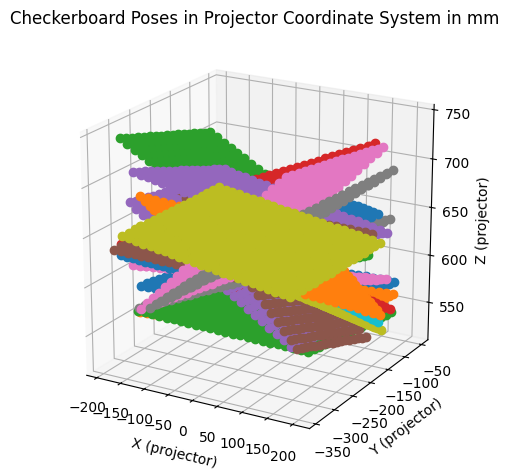

In [141]:
def generate_checkerboard_points(board_size, square_size):
    objp = np.zeros((board_size[0] * board_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:board_size[0], 0:board_size[1]].T.reshape(-1, 2)
    objnew=objp[::-1]
    return objnew * square_size

def showExtrinsics(Checker_Points, rvecs, tvecs):
    """
    Visualizes all checkerboard poses in 3D using the extrinsic parameters
    returned from cv2.calibrateCamera.

    Parameters:
    - Checker_Points: np.ndarray of shape (N, 3), 3D checkerboard points in object coordinates
    - rvecs: list of rotation vectors (from calibrateCamera), one per view
    - tvecs: list of translation vectors (from calibrateCamera), one per view
    """
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for rvec, tvec in zip(rvecs, tvecs):
        # Convert rotation vector to rotation matrix
        R, _ = cv2.Rodrigues(rvec)
        T = np.asarray(tvec).reshape(3, 1)

        # Transform the object points to the camera coordinate system
        transformed_points = (R @ Checker_Points.T + T).T  # shape (N, 3)

        # Plot the transformed checkerboard
        ax.plot(transformed_points[:, 0], transformed_points[:, 1], transformed_points[:, 2], 'o-')

    ax.set_xlabel('X (projector)')
    ax.set_ylabel('Y (projector)')
    ax.set_zlabel('Z (projector)')
    ax.set_title('Checkerboard Poses in Projector Coordinate System in mm')
    ax.view_init(elev=20, azim=-60)
    ax.set_box_aspect([1,1,1])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

squareSize = 15 # 15 mm
worldPoints = generate_checkerboard_points(CHECKERBOARD, squareSize)  #Set up general checkerboard points in 3D object space

print(worldPoints)
showExtrinsics(worldPoints, P_rvecs, P_tvecs)

## referemce 
## https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html